Carregando e preparando os dados...

Iniciando torneio de modelos...
Treinando: Random Forest...
Treinando: XGBoost...
Treinando: Logistic Regression...
Treinando: Gradient Boost...
Treinando: Extra Trees...

 RANKING (F2-Score):
 - XGBoost: 0.7096
 - Logistic Regression: 0.6547
 - Random Forest: 0.6090
 - Gradient Boost: 0.6078
 - Extra Trees: 0.5211

 VENCEDOR: XGBoost

Relatório de Classificação (Threshold Padrão = 0.50):
              precision    recall  f1-score   support

         0.0       0.97      0.74      0.84       204
         1.0       0.45      0.90      0.60        49

    accuracy                           0.77       253
   macro avg       0.71      0.82      0.72       253
weighted avg       0.87      0.77      0.79       253

AUC: 0.8947

Melhor Limiar Otimizado (F2): 0.46

 CENÁRIOS DE CORTE:
 limiar  recall  precision  alunos_acionados
   0.20   1.000      0.212               231
   0.25   0.980      0.318               151
   0.30   0.980      0.356              

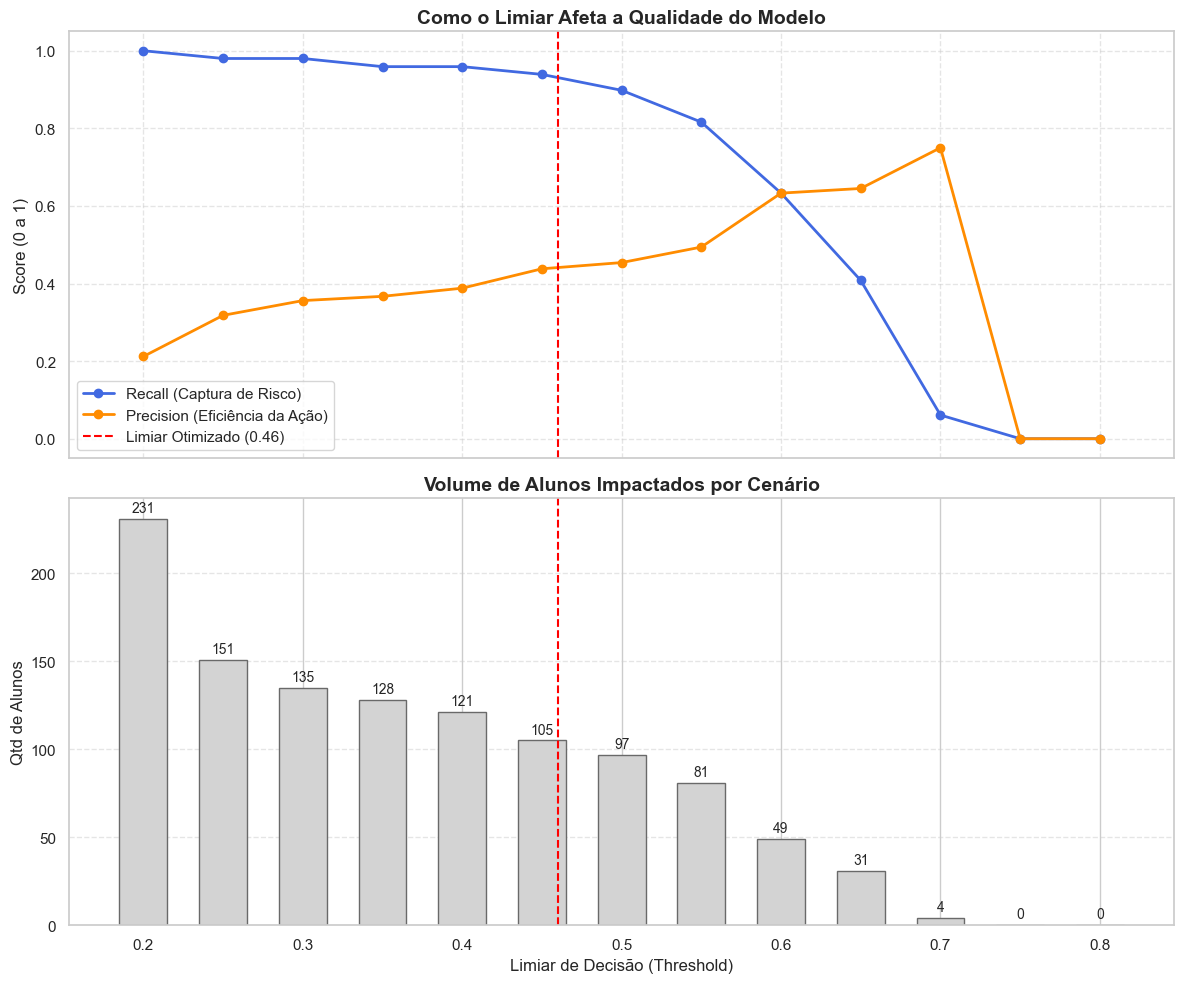


Gerando gráfico SHAP de explicabilidade...


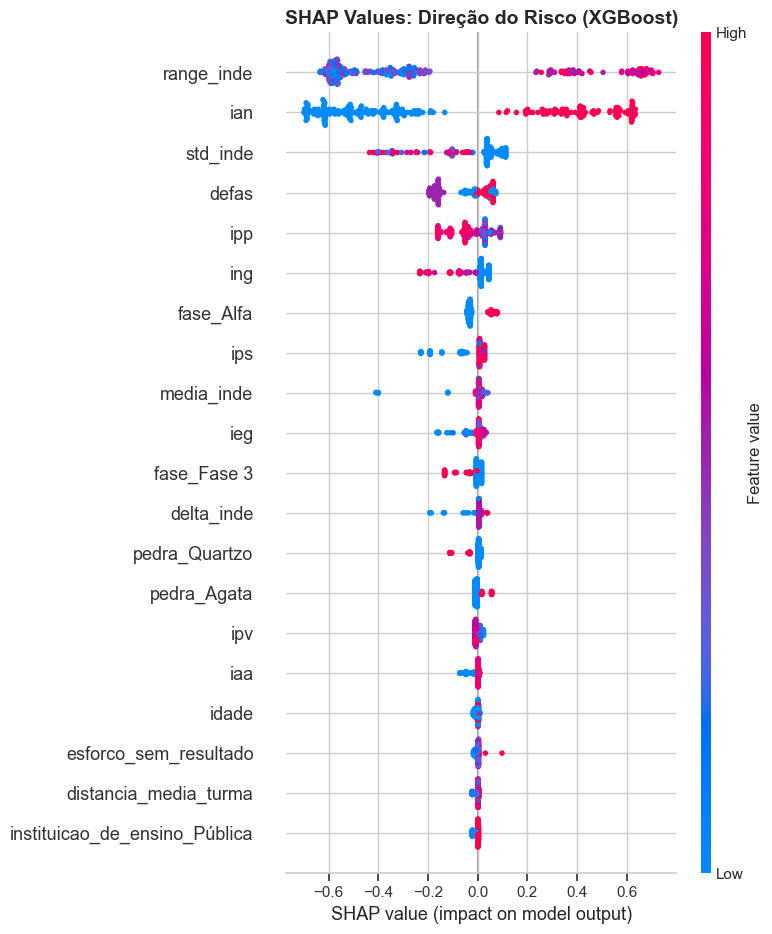


Gerando lista de salvamento para 2024...

 SUCESSO! 334 alunos em risco foram exportados para 'Lista_Prioridade_Salvamento_2024.xlsx'.


In [ ]:
try:
    import numpy as np
except ImportError as e:
    raise ImportError(
        "numpy não está instalado neste kernel. Na raiz do repositório: "
        "python -m venv .venv → ative o venv → pip install -r requirements.txt. "
        "Depois escolha o Python desse .venv como kernel do notebook (README §9)."
    ) from e

import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib

try:
    import shap
except ImportError:
    print("[Aviso] A biblioteca 'shap' não está instalada. O gráfico de direção não será gerado.")

from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score,
    recall_score, precision_score, fbeta_score, make_scorer
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from pathlib import Path

from imblearn.pipeline import Pipeline as ImbPipeline # type: ignore
from imblearn.over_sampling import SMOTE # type: ignore

warnings.filterwarnings('ignore')


def _project_root() -> Path:
    """Raiz do repositório (pasta com `passos_magico/`), independente do cwd do Jupyter."""
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "passos_magico").is_dir():
            return cand
    return p


PROJECT_ROOT = _project_root()
DATA_CSV = PROJECT_ROOT / "notebooks" / "Ml" / "data" / "relatorio_final.csv"
if not DATA_CSV.is_file():
    _alt = PROJECT_ROOT / "notebooks" / "data" / "relatorio_final.csv"
    if _alt.is_file():
        DATA_CSV = _alt
MODEL_PATH = PROJECT_ROOT / "modelo_risco_aluno.pkl"

# 1. CARREGAMENTO + FEATURE ENGINEERING
print("Carregando e preparando os dados...")
print(f"  CSV: {DATA_CSV} (existe: {DATA_CSV.is_file()})")
print(f"  Modelo será salvo em: {MODEL_PATH}")
if not DATA_CSV.is_file():
    raise FileNotFoundError(
        "Não encontrei relatorio_final.csv em notebooks/Ml/data/ nem notebooks/data/. "
        f"Raiz detectada: {PROJECT_ROOT}"
    )
df_ml = pd.read_csv(DATA_CSV)

# Ordenação e deduplicação
df_ml = df_ml.drop_duplicates(subset=['ra', 'ano_referencia'], keep='last')
df_ml = df_ml.sort_values(by=['ra', 'ano_referencia'])

# Criação de variáveis futuras (shift) agrupadas por aluno
grp = df_ml.groupby('ra')
df_ml['ian_prox'] = grp['ian'].shift(-1)
df_ml['inde_prox'] = grp['inde'].shift(-1)
df_ml['ano_prox'] = grp['ano_referencia'].shift(-1)

# Definição do alvo (Vetorizada para maior performance)
cond_ano_valido = (df_ml['ano_prox'] - df_ml['ano_referencia']) == 1
cond_risco = (df_ml['ian_prox'] < df_ml['ian']) | ((df_ml['inde'] - df_ml['inde_prox']) > 1.0)

df_ml['alvo_risco'] = np.where(
    cond_ano_valido & df_ml['ian_prox'].notna(),
    np.where(cond_risco, 1, 0),
    np.nan
)

# Feature Engineering otimizada (reutilizando o objeto 'grp')
df_ml['delta_inde'] = grp['inde'].diff().fillna(0)
df_ml['delta_ian'] = grp['ian'].diff().fillna(0)
df_ml['std_inde'] = grp['inde'].transform(lambda x: x.expanding().std()).fillna(0)
df_ml['media_inde'] = grp['inde'].transform(lambda x: x.expanding().mean())
df_ml['tendencia_inde'] = grp['inde'].transform(lambda x: x.diff().rolling(3).mean()).fillna(0)
df_ml['queda_acumulada_inde'] = grp['inde'].transform(lambda x: x.iloc[0] - x)
df_ml['pior_inde'] = grp['inde'].transform('min')
df_ml['melhor_inde'] = grp['inde'].transform('max')
df_ml['range_inde'] = df_ml['melhor_inde'] - df_ml['pior_inde']

# Novas Features Avançadas (Contexto Pedagógico e Psicológico)
# Fator "Peixe Fora D'água" (Desempenho Relativo)
df_ml['media_turma_inde'] = df_ml.groupby(['instituicao_de_ensino', 'fase', 'ano_referencia'])['inde'].transform('mean')
df_ml['distancia_media_turma'] = df_ml['inde'] - df_ml['media_turma_inde']

# Índice de "Choque de Realidade" (Autoavaliação vs. Realidade)
df_ml['choque_realidade'] = df_ml['iaa'] - df_ml['ida']

# Dinâmica do Esforço vs. Resultado
df_ml['esforco_sem_resultado'] = df_ml['ieg'] / (df_ml['ida'] + 0.1)

# Dinâmica da "Pedra" (Transformando Categoria em Tendência Numérica)
# Alinhado a `passos_magico.ml.risk_pipeline._PEDRA_NUM` (variantes de grafia nos dados)
mapa_pedras = {
    "Quartzo": 1,
    "Ágata": 2,
    "Agata": 2,
    "Ametista": 3,
    "Topázio": 4,
    "Topazio": 4,
}
df_ml['pedra_num'] = df_ml['pedra'].map(mapa_pedras).fillna(0)
df_ml['mudanca_pedra'] = grp['pedra_num'].diff().fillna(0)


# 2. PREPARAÇÃO DOS DADOS

features_num = [
    'idade', 'iaa', 'ieg', 'ips', 'ida', 'ipp', 'ipv', 'ian',
    'mat', 'por', 'ing', 'defas', 'delta_inde', 'delta_ian',
    'std_inde', 'media_inde', 'tendencia_inde', 'queda_acumulada_inde', 'range_inde',
    'distancia_media_turma', 'choque_realidade', 'esforco_sem_resultado', 'mudanca_pedra'
]
features_cat = ['fase', 'genero', 'instituicao_de_ensino', 'pedra']

# Uso do .copy() para evitar SettingWithCopyWarning
base_treino = df_ml[df_ml['alvo_risco'].notnull()].copy()
base_2024 = df_ml[df_ml['ano_referencia'] == 2024].copy()

X = base_treino[features_num + features_cat]
y = base_treino['alvo_risco']
grupos = base_treino['ra']

# Separação Treino/Teste respeitando grupos (alunos)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=grupos))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


# 3. PIPELINE + MÉTRICA

pre_proc = ColumnTransformer(transformers=[
    ('num', Pipeline([ # type: ignore
        ('imp', SimpleImputer(strategy='median')),
        ('std', StandardScaler())
    ]), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_cat)
])

# F2-Score dá mais peso ao Recall (ideal para identificar alunos em risco)
f2_scorer = make_scorer(fbeta_score, beta=2)

def treinar_competidor(nome, modelo, params):
    print(f"Treinando: {nome}...")
    pipe = ImbPipeline([
        ('pre', pre_proc),
        ('smote', SMOTE(random_state=42)),
        ('clf', modelo)
    ])

    search = RandomizedSearchCV(
        pipe, params, n_iter=20, cv=GroupKFold(n_splits=3),
        scoring=f2_scorer, n_jobs=-1, random_state=42
    )
    search.fit(X_train, y_train, groups=grupos.iloc[train_idx])
    return search.best_estimator_, search.best_score_


# 4. TREINAMENTO DOS MODELOS

print("\nIniciando torneio de modelos...")
competidores = [
    ("Random Forest", RandomForestClassifier(random_state=42), {
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [5, 8, 12]
    }),
    ("XGBoost", XGBClassifier(random_state=42, eval_metric='logloss'), {
        'clf__n_estimators': [100, 200, 300],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__max_depth': [3, 5, 7],
        'clf__subsample': [0.7, 0.9, 1],
        'clf__colsample_bytree': [0.7, 0.9, 1]
    }),
    ("Logistic Regression", LogisticRegression(max_iter=1000), {
        'clf__C': [0.1, 1, 10]
    }),
    ("Gradient Boost", GradientBoostingClassifier(random_state=42), {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.05, 0.1]
    }),
    ("Extra Trees", ExtraTreesClassifier(random_state=42), {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [5, 10, 15]
    })
]

melhor_modelo = None
melhor_score = -1
vencedor = ""
ranking = []

for nome, modelo, params in competidores:
    m, score = treinar_competidor(nome, modelo, params)
    ranking.append((nome, score))
    if score > melhor_score:
        melhor_modelo = m
        melhor_score = score
        vencedor = nome

ranking = sorted(ranking, key=lambda x: x[1], reverse=True)

print("\n RANKING (F2-Score):")
for n, s in ranking:
    print(f" - {n}: {s:.4f}")


# 5. AVALIAÇÃO DO VENCEDOR

preds = melhor_modelo.predict(X_test)
prob_test = melhor_modelo.predict_proba(X_test)[:, 1]

print(f"\n VENCEDOR: {vencedor}")
print("\nRelatório de Classificação (Threshold Padrão = 0.50):")
print(classification_report(y_test, preds))

auc = roc_auc_score(y_test, prob_test)
print(f"AUC: {auc:.4f}")


# 6. OTIMIZAÇÃO DE LIMIAR (THRESHOLD)

best_limiar = 0
best_f2 = 0

for l in np.arange(0.2, 0.81, 0.01):
    p = (prob_test >= l).astype(int)
    if p.sum() > 0: 
        score = fbeta_score(y_test, p, beta=2)
        if score > best_f2:
            best_f2 = score
            best_limiar = l

print(f"\nMelhor Limiar Otimizado (F2): {best_limiar:.2f}")


# 7. ANÁLISE DE CENÁRIOS

cenarios = []
for l in np.arange(0.2, 0.85, 0.05):
    p = (prob_test >= l).astype(int)
    cenarios.append({
        'limiar': round(l, 2),
        'recall': round(recall_score(y_test, p), 3),
        'precision': round(precision_score(y_test, p, zero_division=0), 3),
        'alunos_acionados': p.sum()
    })

df_cenarios = pd.DataFrame(cenarios)
print("\n CENÁRIOS DE CORTE:")
print(df_cenarios.to_string(index=False))


# 8. GRÁFICOS: CENÁRIOS DE CORTE E VOLUME

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(df_cenarios['limiar'], df_cenarios['recall'], marker='o', 
         label='Recall (Captura de Risco)', color='royalblue', linewidth=2)
ax1.plot(df_cenarios['limiar'], df_cenarios['precision'], marker='o', 
         label='Precision (Eficiência da Ação)', color='darkorange', linewidth=2)
ax1.axvline(x=best_limiar, color='red', linestyle='--', label=f'Limiar Otimizado ({best_limiar:.2f})')

ax1.set_ylabel('Score (0 a 1)', fontsize=12)
ax1.set_title('Como o Limiar Afeta a Qualidade do Modelo', fontsize=14, fontweight='bold')
ax1.legend(loc='lower left')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.bar(df_cenarios['limiar'], df_cenarios['alunos_acionados'], width=0.03, 
        color='lightgray', edgecolor='dimgray', label='Alunos em Risco')
ax2.axvline(x=best_limiar, color='red', linestyle='--')

for i, txt in enumerate(df_cenarios['alunos_acionados']):
    ax2.annotate(txt, (df_cenarios['limiar'].iloc[i], df_cenarios['alunos_acionados'].iloc[i]),
                 textcoords="offset points", xytext=(0, 5), ha='center', fontsize=10)

ax2.set_xlabel('Limiar de Decisão (Threshold)', fontsize=12)
ax2.set_ylabel('Qtd de Alunos', fontsize=12)
ax2.set_title('Volume de Alunos Impactados por Cenário', fontsize=14, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# 9. EXPLAINABILITY: SHAP & FEATURE IMPORTANCE

try:
    print("\nGerando gráfico SHAP de explicabilidade...")
    # Extrai o pré-processador e o modelo final do pipeline
    pre_processador = melhor_modelo.named_steps['pre']
    modelo_final = melhor_modelo.named_steps['clf']
    
    # Transforma os dados de teste para o formato puro que o modelo lê
    X_test_transformado = pre_processador.transform(X_test)
    
    # Limpa os nomes das features
    features_brutas = pre_processador.get_feature_names_out()
    features_limpas = [f.split('__')[-1] for f in features_brutas]
    
    # SHAP Explainer
    explainer = shap.Explainer(modelo_final)
    shap_values = explainer(X_test_transformado)
    
    # Plot do SHAP
    plt.figure(figsize=(10, 8))
    plt.title(f'SHAP Values: Direção do Risco ({vencedor})', fontsize=14, fontweight='bold')
    shap.summary_plot(shap_values, X_test_transformado, feature_names=features_limpas, show=True)

except Exception as e:
    print(f"\n[Aviso] Não foi possível gerar SHAP ({e}). Gerando gráfico padrão de barras...")
    importances = melhor_modelo.named_steps['clf'].feature_importances_
    features = melhor_modelo.named_steps['pre'].get_feature_names_out()
    features_limpas = [f.split('__')[-1] for f in features]
    
    df_imp = pd.DataFrame({'feature': features_limpas, 'importance': importances}).sort_values(by='importance')
    df_top = df_imp.tail(15)

    plt.figure(figsize=(10, 8))
    plt.barh(df_top['feature'], df_top['importance'], color='teal', edgecolor='black')
    plt.title(f'Top 15 Variáveis Mais Importantes ({vencedor})', fontsize=14, fontweight='bold')
    plt.xlabel('Nível de Importância', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


# 10. EXPORTAÇÃO FINAL E SALVAMENTO 

print("\nGerando lista de salvamento para 2024...")

# Escoragem da base de 2024
X_2024 = base_2024[features_num + features_cat]
prob_2024 = melhor_modelo.predict_proba(X_2024)[:, 1]

base_2024['Probabilidade_Risco_Valor'] = (prob_2024 * 100).round(1)

# Filtro usando o threshold matemático otimizado
planilha = base_2024[base_2024['Probabilidade_Risco_Valor'] >= (best_limiar * 100)]

colunas_exportacao = [
    'ra', 'nome', 'fase', 'instituicao_de_ensino', 
    'inde', 'ian', 'Probabilidade_Risco_Valor'
]

planilha = planilha[colunas_exportacao].sort_values(by='Probabilidade_Risco_Valor', ascending=False)
planilha.to_excel('Lista_Prioridade_Salvamento_2024.xlsx', index=False)

# Mesmo caminho que `passos_magico.ml.inference.PRIMARY_MODEL_PATH` (raiz do projeto)
joblib.dump(melhor_modelo, MODEL_PATH)

print(f"\n SUCESSO! {len(planilha)} alunos em risco foram exportados para 'Lista_Prioridade_Salvamento_2024.xlsx'.")

Iniciando Bateria de Testes Visuais...



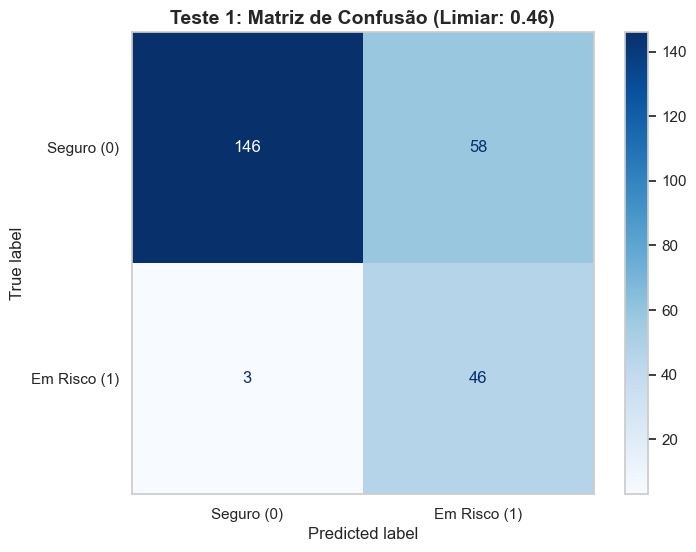

--------------------------------------------------
 DADOS PARA COPIAR: TESTE 1 (Matriz de Confusão)
Verdadeiros Negativos (Seguros que acertamos): 146
Falsos Positivos (Alarmes falsos): 58
Falsos Negativos (Deixamos passar): 3  <-- ATENÇÃO AQUI
Verdadeiros Positivos (Alunos salvos): 46
-------------------------------------------------- 



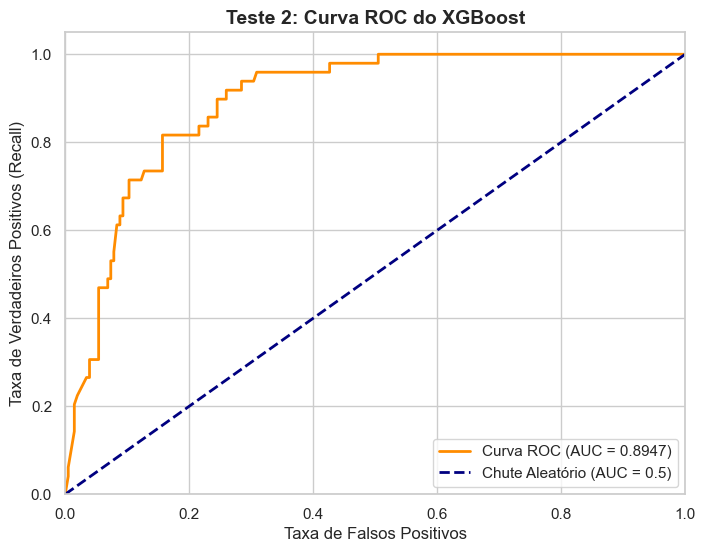

--------------------------------------------------
 DADOS PARA COPIAR: TESTE 2 (Qualidade Geral)
Score AUC:  0.8947 (Ideal mais próximo de 1.0)
Índice Gini: 0.7893 (Ideal mais próximo de 1.0)
-------------------------------------------------- 



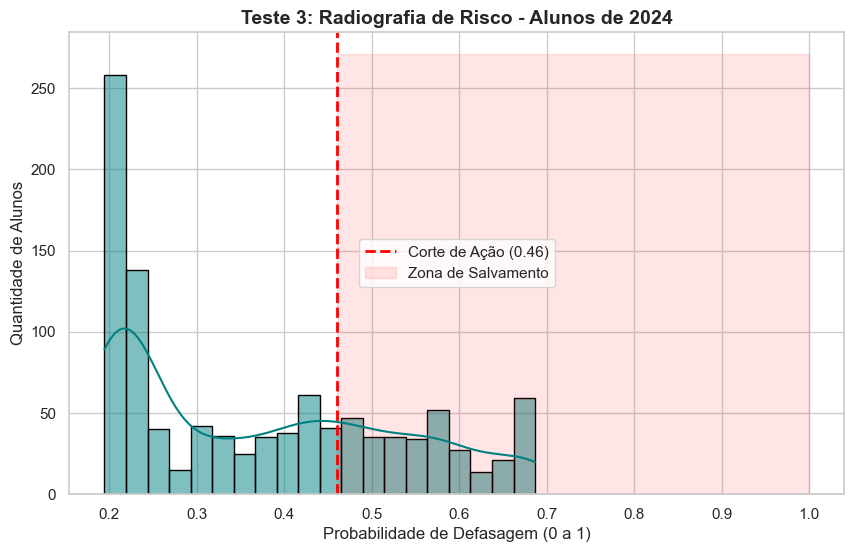

--------------------------------------------------
 DADOS PARA COPIAR: TESTE 3 (Radiografia 2024)
Total de Alunos em 2024 avaliados: 1053
Alunos na Zona de Risco (>= 0.46): 336 (31.9%)
Alunos Seguros (< 0.46): 717 (68.1%)
-------------------------------------------------- 



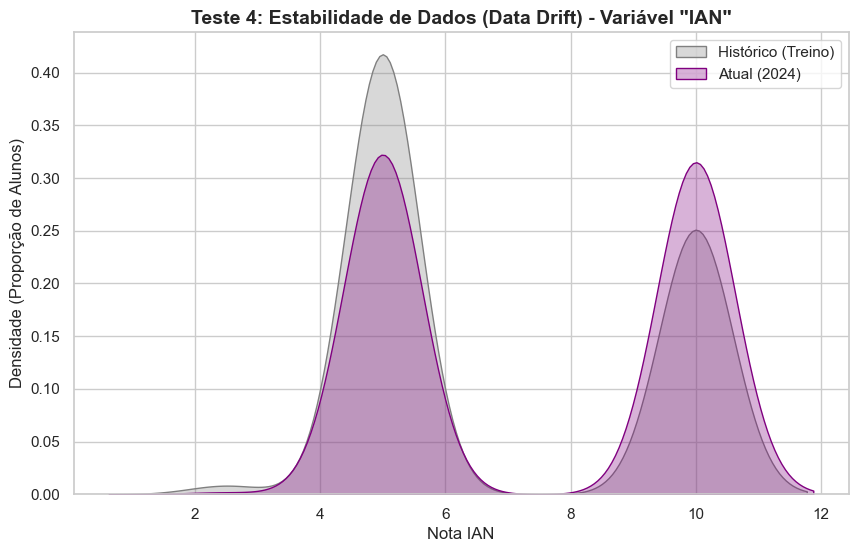

--------------------------------------------------
 DADOS PARA COPIAR: TESTE 4 (Estabilidade IAN)
Média do IAN Histórico (Treino): 6.82
Média do IAN Atual (2024):      7.46
Diferença nas médias:           0.63
-------------------------------------------------- 

 Testes Visuais Concluídos! Copie os dados acima e mande no chat.


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

# Configuração de estilo para gráficos mais profissionais
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

print("Iniciando Bateria de Testes Visuais...\n")

# TESTE 1: MATRIZ DE CONFUSÃO (Onde o modelo erra?)

fig, ax = plt.subplots(figsize=(8, 6))
preds_test = (melhor_modelo.predict_proba(X_test)[:, 1] >= best_limiar).astype(int)
cm = confusion_matrix(y_test, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Seguro (0)', 'Em Risco (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title(f'Teste 1: Matriz de Confusão (Limiar: {best_limiar:.2f})', fontsize=14, fontweight='bold')
plt.grid(False) 
plt.show()

# --- PRINT DOS DADOS PARA O CHAT ---
tn, fp, fn, tp = cm.ravel()
print("-" * 50)
print(" DADOS PARA COPIAR: TESTE 1 (Matriz de Confusão)")
print(f"Verdadeiros Negativos (Seguros que acertamos): {tn}")
print(f"Falsos Positivos (Alarmes falsos): {fp}")
print(f"Falsos Negativos (Deixamos passar): {fn}  <-- ATENÇÃO AQUI")
print(f"Verdadeiros Positivos (Alunos salvos): {tp}")
print("-" * 50, "\n")



# TESTE 2: CURVA ROC (Qualidade Geral de Separação)

fpr, tpr, thresholds = roc_curve(y_test, prob_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chute Aleatório (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=12)
plt.title('Teste 2: Curva ROC do XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

# --- PRINT DOS DADOS PARA O CHAT ---
gini = (2 * auc) - 1
print("-" * 50)
print(" DADOS PARA COPIAR: TESTE 2 (Qualidade Geral)")
print(f"Score AUC:  {auc:.4f} (Ideal mais próximo de 1.0)")
print(f"Índice Gini: {gini:.4f} (Ideal mais próximo de 1.0)")
print("-" * 50, "\n")



# TESTE 3: DISTRIBUIÇÃO DE PROBABILIDADES EM 2024

plt.figure(figsize=(10, 6))
sns.histplot(prob_2024, bins=20, kde=True, color='teal', edgecolor='black')

plt.axvline(best_limiar, color='red', linestyle='--', linewidth=2, label=f'Corte de Ação ({best_limiar:.2f})')
plt.fill_betweenx([0, plt.gca().get_ylim()[1]], best_limiar, 1.0, color='red', alpha=0.1, label='Zona de Salvamento')

plt.title('Teste 3: Radiografia de Risco - Alunos de 2024', fontsize=14, fontweight='bold')
plt.xlabel('Probabilidade de Defasagem (0 a 1)', fontsize=12)
plt.ylabel('Quantidade de Alunos', fontsize=12)
plt.legend()
plt.show()

# --- PRINT DOS DADOS PARA O CHAT ---
alunos_risco_2024 = (prob_2024 >= best_limiar).sum()
alunos_seguros_2024 = (prob_2024 < best_limiar).sum()
total_2024 = len(prob_2024)

print("-" * 50)
print(" DADOS PARA COPIAR: TESTE 3 (Radiografia 2024)")
print(f"Total de Alunos em 2024 avaliados: {total_2024}")
print(f"Alunos na Zona de Risco (>= {best_limiar:.2f}): {alunos_risco_2024} ({(alunos_risco_2024/total_2024)*100:.1f}%)")
print(f"Alunos Seguros (< {best_limiar:.2f}): {alunos_seguros_2024} ({(alunos_seguros_2024/total_2024)*100:.1f}%)")
print("-" * 50, "\n")


# TESTE 4: TESTE DE ESTABILIDADE (DATA DRIFT)

plt.figure(figsize=(10, 6))

sns.kdeplot(base_treino['ian'].dropna(), label='Histórico (Treino)', color='gray', fill=True, alpha=0.3)
sns.kdeplot(base_2024['ian'].dropna(), label='Atual (2024)', color='purple', fill=True, alpha=0.3)

plt.title('Teste 4: Estabilidade de Dados (Data Drift) - Variável "IAN"', fontsize=14, fontweight='bold')
plt.xlabel('Nota IAN', fontsize=12)
plt.ylabel('Densidade (Proporção de Alunos)', fontsize=12)
plt.legend()
plt.show()

# --- PRINT DOS DADOS PARA O CHAT ---
media_treino = base_treino['ian'].mean()
media_2024 = base_2024['ian'].mean()

print("-" * 50)
print(" DADOS PARA COPIAR: TESTE 4 (Estabilidade IAN)")
print(f"Média do IAN Histórico (Treino): {media_treino:.2f}")
print(f"Média do IAN Atual (2024):      {media_2024:.2f}")
print(f"Diferença nas médias:           {abs(media_treino - media_2024):.2f}")
print("-" * 50, "\n")

print(" Testes Visuais Concluídos! Copie os dados acima e mande no chat.")

In [28]:
# --- TESTE DE ESTRESSE POR ANO ---
print(" VALIDANDO PERFORMANCE ANO A ANO:\n")

for ano in [2022, 2023]:
    # Filtra os dados daquele ano específico que o modelo NÃO usou para decidir o alvo final
    base_ano = base_treino[base_treino['ano_referencia'] == ano]
    
    if len(base_ano) > 0:
        X_ano = base_ano[features_num + features_cat]
        y_ano = base_ano['alvo_risco']
        
        # Predição com o limiar otimizado
        prob_ano = melhor_modelo.predict_proba(X_ano)[:, 1]
        pred_ano = (prob_ano >= best_limiar).astype(int)
        
        # Métricas
        rec = recall_score(y_ano, pred_ano)
        prec = precision_score(y_ano, pred_ano, zero_division=0)
        
        print(f" Resultados para o Ano {ano}:")
        print(f"   - Alunos Avaliados: {len(base_ano)}")
        print(f"   - Recall (Captura): {rec:.2%}")
        print(f"   - Precisão:         {prec:.2%}")
        print("-" * 30)

 VALIDANDO PERFORMANCE ANO A ANO:

 Resultados para o Ano 2022:
   - Alunos Avaliados: 570
   - Recall (Captura): 98.17%
   - Precisão:         39.63%
------------------------------
 Resultados para o Ano 2023:
   - Alunos Avaliados: 678
   - Recall (Captura): 93.53%
   - Precisão:         51.79%
------------------------------


---

# Relatório: Modelo Preditivo de Risco de Defasagem Escolar

## 1. Feature Engineering (Engenharia de Variáveis)
Para aumentar a precisão do modelo, foram criadas variáveis que capturam o comportamento temporal e o contexto psicopedagógico dos alunos:

*   **Variáveis de Instabilidade (Sazonais):**
    *   `range_inde`: Diferença entre a maior e a menor nota do aluno (mede oscilação).
    *   `std_inde`: Desvio padrão das notas (mede a irregularidade do desempenho).
    *   `delta_ian` / `delta_inde`: Evolução direta entre o ano atual e o anterior.
*   **Variáveis de Contexto e Comportamento:**
    *   `distancia_media_turma`: Desempenho do aluno em relação aos seus pares diretos.
    *   `choque_realidade`: Diferença entre a autoavaliação do aluno (`iaa`) e sua nota real (`ida`).
    *   `esforco_sem_resultado`: Razão entre o engajamento (`ieg`) e a aprendizagem efetiva.
    *   `mudanca_pedra`: Transformação da classificação qualitativa em numérica para medir regressão de nível.

## 2. Técnicas Utilizadas no Modelo
O desenvolvimento seguiu rigorosos padrões de "Machine Learning " para garantir robustez e evitar alarmes falsos:

*   **Algoritmo Vencedor:** **XGBoost Classifier**, selecionado após torneio com Random Forest, Regressão Logística e Gradient Boosting.
*   **Protocolo de Validação:**
    *   `GroupShuffleSplit` e `GroupKFold`: Separação de treino e teste baseada no RA do aluno, garantindo que o modelo seja testado em alunos nunca vistos, evitando o vazamento de dados.
*   **Tratamento de Dados:**
    *   `SMOTE` (dentro de Pipeline): Balanceamento sintético da classe minoritária (alunos em risco), permitindo que o modelo "aprenda" o perfil da defasagem mesmo com poucos exemplos.
    *   `StandardScaler` e `SimpleImputer`: Padronização de escalas e tratamento de dados ausentes por mediana.
*   **Métrica de Negócio:**
    *   **F2-Score**: Priorização do *Recall* sobre a *Precision*, pois o custo pedagógico de ignorar um aluno em risco é maior do que o custo de atender um aluno que não precisava.

## 3. Validação e Resultados
Os testes confirmaram a estabilidade e a alta capacidade de captura do modelo:

*   **Poder de Separação (AUC):** **0.8947** (Excelente capacidade de distinguir perfis de risco e segurança).
*   **Matriz de Confusão (Teste):**
    *   **Recall de 94%**: O modelo identificou 46 dos 49 alunos que realmente entraram em defasagem.
    *   **Apenas 3 "Falsos Negativos"**: Pouquíssimos alunos em risco ficaram invisíveis ao sistema.
*   **Validação Cronológica (Backtesting):**
    *   Performance em 2022: **98.17%** de captura.
    *   Performance em 2023: **93.53%** de captura.
    *   Isso prova que o modelo é **atemporal** e não depende de uma turma específica.

## 4. Insights e Recomendações
*   **O "Radar de Instabilidade":** O `range_inde` e o `std_inde` estão no topo da importância. Alunos com notas que oscilam muito ("montanha-russa") possuem risco de queda iminente superior aos alunos constantemente medianos.
*   **Pontos de Quebra:** As fases **Alfa** (alfabetização) e **Fase 3** foram identificadas como gargalos críticos de aprendizagem.
*   **Estratégia de Corte (Limiar):**
    *   O limiar matemático ideal é **46%**.
    *   Para a base de 2024 (1.053 alunos), isso gera uma lista de **334 alunos prioritários**.
    *   **Insight de Atendimento:** Recomenda-se ordenar a lista pela probabilidade e iniciar o acolhimento pelos alunos com risco acima de **65%** caso a capacidade operacional da equipe seja limitada.

---

In [2]:
import pandas as pd
from pathlib import Path


def _project_root() -> Path:
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "passos_magico").is_dir():
            return cand
    return p


ROOT = _project_root()
DATA_CSV = ROOT / "notebooks" / "Ml" / "data" / "relatorio_final.csv"
if not DATA_CSV.is_file():
    _a = ROOT / "notebooks" / "data" / "relatorio_final.csv"
    if _a.is_file():
        DATA_CSV = _a

# Parquet no mesmo lugar que `passos_magico.data_engine.loader.NOTEBOOK_ML_PARQUET`
PARQUET_OUT = ROOT / "notebooks" / "Ml" / "relatorio_final.parquet"

df = pd.read_csv(DATA_CSV)
df.to_parquet(PARQUET_OUT, index=False)
print(f"Conversão concluída: {PARQUET_OUT}")

Conversão concluída com sucesso!
